# Прогноза на соларна продукција — машинско учење

**Maria Mitrikeska · 2026**

---

## Што правиме овде?

Градиме модел кој одговара на **едно прашање**:

> „Колку kW струја ќе произведат соларните панели во даден час?"

### Зошто ни треба тоа?

Батеријата мора да **планира однапред**. За да одлучи кога да се полни и празни,
мора да знае колку сонце ќе има утре:

```
1. XGBoost ГЛЕДА:   час, сезона, температура, облачност, вчерашна продукција
        ↓
2. XGBoost КАЖУВА:  „утре во 12ч панелите ќе дадат 4.2 kW"
        ↓
3. LP ја зема прогнозата како ВЛЕЗ
        ↓
4. LP ПРЕСМЕТУВА:   „полни во 11-14ч, празни во 18-21ч"
        ↓
5. Батеријата го следи планот → МИНИМАЛНА СМЕТКА
```

**ML = ГАТАЧОТ** (само предвидува)
**LP = ПЛАНЕРОТ** (само одлучува)

Овој notebook го покрива **чекор 1 и 2**.

---
## 1. Библиотеки

Ги вчитуваме алатките што ќе ни требаат.

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Стил на графиконите
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.titlesize"] = 13

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Библиотеките се вчитани.")

Библиотеките се вчитани.


---
## 2. Вчитување на податоците

Два извори, обата реални:

| Извор | Што дава | Период |
|---|---|---|
| **PVGIS** (Европска комисија) | соларна продукција + температура | 2021-2023 |
| **Open-Meteo** | облачност, влажност, ветар | 2021-2023 |

Часовна резолуција → ~26.000 реда.

In [6]:
# --- Сончеви податоци (PVGIS) ---
pv = pd.read_csv("data/pvgis_skopje.csv", index_col=0, parse_dates=True)
pv.index = pd.to_datetime(pv.index, utc=True)

# --- Метеоролошки податоци (Open-Meteo) ---
vreme = pd.read_csv("data/vreme_skopje.csv", index_col=0, parse_dates=True)
vreme.index = pd.to_datetime(vreme.index, utc=True)

print(f"PVGIS:  {pv.shape[0]:,} реда · колони: {list(pv.columns)}")
print(f"Време:  {vreme.shape[0]:,} реда · колони: {list(vreme.columns)}")

PVGIS:  35,064 реда · колони: ['pv_power_w', 'ghi', 'sun_alt', 'temp_air', 'wind_speed', 'pv_power_kw']
Време:  26,280 реда · колони: ['temp_air', 'humidity', 'dew_point', 'precip', 'cloud_cover', 'cloud_low', 'cloud_mid', 'cloud_high', 'ghi', 'dhi_direct', 'dhi', 'dni', 'wind_speed', 'wind_dir', 'pressure']


### 2.1 Отфрлање на непотребните колони

Не сè што дојде од API-то ни треба. Задржуваме само она што **логично влијае**
на соларната продукција:

**Задржуваме:**
- `pv_power_kw` — тоа што го предвидуваме (целна променлива)
- `temp_air` — жешки панели работат полошо
- `cloud_cover`, `cloud_low/mid/high` — облаците го блокираат сонцето
- `humidity` — индикатор за магла
- `wind_speed` — ветарот ги лади панелите

**Фрламе:**
- `pv_power_w` — дупликат на `pv_power_kw` (само друга единица)
- `sun_alt` — детерминистички се пресметува од час и датум (веќе го имаме)
- `dni`, `dhi`, `dhi_direct` — истиот проблем како `ghi` (види долу)
- `dew_point`, `precip`, `pressure`, `wind_dir` — слаба поврзаност

> ⚠️ **Најважно: зошто го фрламе `ghi`?**
>
> `ghi` е измерената сончева радијација во **истиот час**. PVGIS ја пресметува
> PV моќноста **директно од неа** по физичка формула. Ако му ја дадеме на
> моделот, тој само ќе „препишува" наместо да учи — тоа се вика **data leakage**.
>
> Грешката паѓа на скоро нула, но моделот е бескорисен во пракса: утре ја
> знаеме прогнозата за облаци, но **не и измерената радијација**.

In [7]:
# Од PVGIS: само продукцијата и температурата
pv = pv[["pv_power_kw", "temp_air"]]

# Од Open-Meteo: облачност и придружни (wind_speed веќе го има PVGIS)
vreme = vreme[["cloud_cover", "cloud_low", "cloud_mid", "cloud_high",
               "humidity", "wind_speed"]]

# ⚠ ВАЖНО: двата извора покриваат РАЗЛИЧНИ периоди!
#   PVGIS: 2020-2023  ·  Open-Meteo: 2021-2023
# Ако ги споиме со ffill/bfill, 2020 ќе добие ИЗМИСЛЕНА облачност
# (копирана од 2021). Затоа земаме само каде ги имаме ОБАТА извора.
df = pv.join(vreme, how="inner")     # inner = само преклопувачкиот период

print(f"PVGIS период:  {pv.index.min().date()} → {pv.index.max().date()}")
print(f"Метео период:  {vreme.index.min().date()} → {vreme.index.max().date()}")
print(f"Преклопување:  {df.index.min().date()} → {df.index.max().date()}")
print(f"\nФинална табела: {df.shape[0]:,} реда × {df.shape[1]} колони")
print(f"Празни вредности: {df.isna().sum().sum()}")
df.head()

PVGIS период:  2020-01-01 → 2023-12-31
Метео период:  2021-01-01 → 2023-12-31
Преклопување:  2021-01-01 → 2023-12-31

Финална табела: 26,280 реда × 8 колони
Празни вредности: 0


,pv_power_kw,temp_air,cloud_cover,cloud_low,cloud_mid,cloud_high,humidity,wind_speed
time,,,,,,,,
2021-01-01 00:00:00+00:00,0.0,1.75,0,0,6,1,68,7.1
2021-01-01 01:00:00+00:00,0.0,1.57,1,1,1,0,68,7.0
2021-01-01 02:00:00+00:00,0.0,1.03,2,1,1,0,69,4.7
2021-01-01 03:00:00+00:00,0.0,0.46,2,2,2,0,72,2.9
2021-01-01 04:00:00+00:00,0.0,0.11,2,2,1,0,75,2.5


In [8]:
# Основна статистика — проверка дека вредностите се разумни
df.describe().round(2)

,pv_power_kw,temp_air,cloud_cover,cloud_low,cloud_mid,cloud_high,humidity,wind_speed
count,26280.00,26280.00,26280.00,26280.00,26280.00,26280.00,26280.00,26280.00
mean,0.75,12.62,47.43,16.58,24.99,31.94,64.37,5.44
std,1.14,9.57,41.65,30.33,34.67,40.79,19.37,2.73
min,0.00,-19.75,0.00,0.00,0.00,0.00,11.00,0.00
25%,0.00,5.12,3.00,0.00,0.00,0.00,50.00,3.60
50%,0.00,12.09,39.00,0.00,6.00,3.00,66.00,5.10
75%,1.30,19.89,98.00,16.00,38.00,77.00,80.00,6.80
max,4.21,38.28,100.00,100.00,100.00,100.00,100.00,26.10


---
## 3. Разгледување на податоците (EDA)

Пред да градиме модел, треба да ги **видиме** податоците. Ако тие немаат смисла,
ни моделот нема да има.

### 📊 Графикон 1: Дневна крива на соларната продукција

**Што прикажува:** просечна продукција за секој час од денот.

**Што очекуваме:** камбанеста форма — нула ноќе, пик околу пладне.

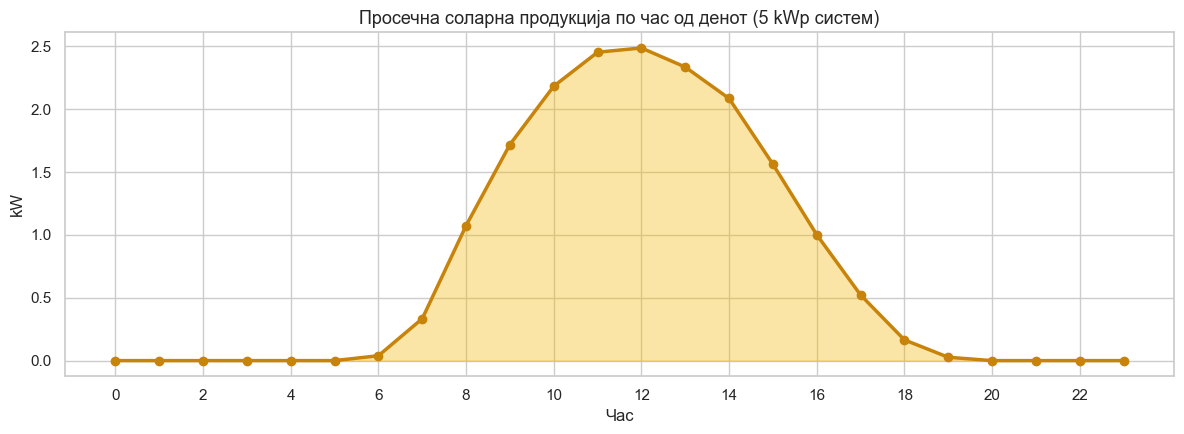

Пик во 12:00 часот → 2.49 kW
Ноќе (00-04ч) → 0.000 kW  (како што и треба)


In [9]:
# Локално време (важно! UTC не е нашето време)
lokalno = df.index.tz_convert("Europe/Skopje")
df["cas"] = lokalno.hour
df["mesec"] = lokalno.month

po_cas = df.groupby("cas")["pv_power_kw"].mean()

fig, ax = plt.subplots()
ax.fill_between(po_cas.index, po_cas.values, alpha=0.35, color="#F5B700")
ax.plot(po_cas.index, po_cas.values, color="#C8830A", linewidth=2.5, marker="o")
ax.set_title("Просечна соларна продукција по час од денот (5 kWp систем)")
ax.set_xlabel("Час"); ax.set_ylabel("kW")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()

print(f"Пик во {po_cas.idxmax()}:00 часот → {po_cas.max():.2f} kW")
print(f"Ноќе (00-04ч) → {po_cas.loc[0:4].mean():.3f} kW  (како што и треба)")

### 📊 Графикон 2: Сезонска варијација

**Што прикажува:** колку сонце има во секој месец.

**Зошто е важно:** декември има **3-4× помалку** од јули. Затоа батеријата
се однесува сосема различно зиме и лете — и затоа симулираме 4 сезонски недели.

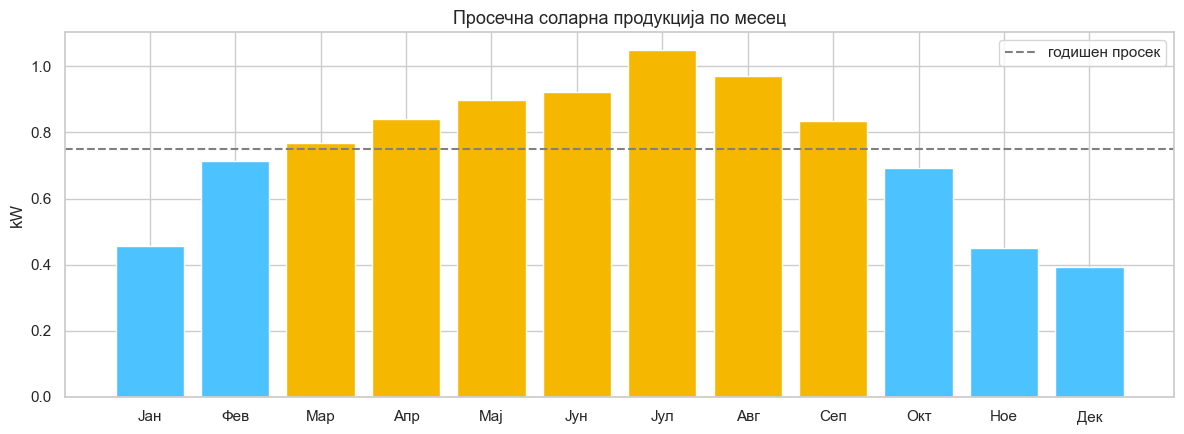

Најсилен: Јул (1.05 kW)
Најслаб:  Дек (0.39 kW)
Сооднос лето/зима: 2.7×


In [10]:
po_mesec = df.groupby("mesec")["pv_power_kw"].mean()
imina = ["Јан","Фев","Мар","Апр","Мај","Јун","Јул","Авг","Сеп","Окт","Ное","Дек"]

fig, ax = plt.subplots()
boi = ["#4CC2FF" if v < po_mesec.mean() else "#F5B700" for v in po_mesec.values]
ax.bar(imina, po_mesec.values, color=boi, edgecolor="white")
ax.axhline(po_mesec.mean(), color="gray", linestyle="--", label="годишен просек")
ax.set_title("Просечна соларна продукција по месец")
ax.set_ylabel("kW"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Најсилен: {imina[po_mesec.idxmax()-1]} ({po_mesec.max():.2f} kW)")
print(f"Најслаб:  {imina[po_mesec.idxmin()-1]} ({po_mesec.min():.2f} kW)")
print(f"Сооднос лето/зима: {po_mesec.max()/po_mesec.min():.1f}×")

### 📋 Табела: една недела во јуни — час по час

**Што прикажува:** точни вредности за 3 дена (17-19 јуни 2023) — колку
kW произвеле панелите во секој час, со временските услови.

**Зошто:** графиконите даваат слика, но табелата ги дава **точните бројки**.
Тука се гледа директно врската облачност → продукција.

In [11]:
# Три дена во јуни (најсилниот сончев период)
nedela = df.loc["2023-06-17":"2023-06-19"].copy()
nedela.index = nedela.index.tz_convert("Europe/Skopje")

# Само дневни часови — ноќе е сè нула, не носи информација
tabela = nedela[(nedela["cas"] >= 5) & (nedela["cas"] <= 20)][
    ["pv_power_kw", "cloud_cover", "temp_air"]
].round(2)
tabela.columns = ["Продукција (kW)", "Облачност (%)", "Температура (°C)"]
tabela.index = tabela.index.strftime("%d.%m %H:%M")

print(f"Вкупно за 3 дена: {nedela['pv_power_kw'].sum():.1f} kWh")
print(f"Максимум: {nedela['pv_power_kw'].max():.2f} kW")
print()
tabela

Вкупно за 3 дена: 37.0 kWh
Максимум: 3.25 kW



,Продукција (kW),Облачност (%),Температура (°C)
time,,,
17.06 05:00,0.00,100,13.76
17.06 06:00,0.01,100,13.89
17.06 07:00,0.06,100,14.17
17.06 08:00,0.18,100,14.65
17.06 09:00,0.43,100,14.85
17.06 10:00,0.53,100,15.34
17.06 11:00,0.43,100,15.73
17.06 12:00,0.42,100,15.95
17.06 13:00,0.27,100,16.32


### 🔬 Како PVGIS ја пресметува продукцијата?

Тоа НЕ е измерена вредност — тоа е **пресметка** по физичка формула:

$$P = P_{nom} \times \frac{G_{POA}}{1000} \times \left[1 + \gamma (T_{cell} - 25)\right] \times (1 - L)$$

| Симбол | Значење | Кај нас |
|---|---|---|
| $P_{nom}$ | номинална моќност на системот | 5 kWp |
| $G_{POA}$ | сонце на **рамнината на панелите** (W/m²) | од сателит |
| $1000$ | референтни услови (STC) | константа |
| $\gamma$ | температурен коефициент | ≈ −0.004 /°C |
| $T_{cell}$ | температура на **ќелијата** (не на воздух!) | пресметана |
| $L$ | системски загуби | 14% |

**Чекор по чекор:**

1. **Сателитот** мери колку сонце паѓа на земјата (GHI)
2. **Геометрија** — се пресметува колку паѓа на наклонети панели под 30° кон југ → $G_{POA}$
3. **Температура на ќелија** — панелот е потопол од воздухот:
   $T_{cell} \approx T_{воздух} + \frac{G_{POA}}{800} \times 25$
4. **Температурна загуба** — за секој степен над 25°C, ефикасноста паѓа ~0.4%
5. **Системски загуби** — инвертор, кабли, прашина: −14%

> ⚠️ **Токму затоа GHI е data leakage!**
> Ако му го дадеме GHI на моделот, тој само ја применува формулата наназад —
> не учи ништо. Затоа моделот учи од **облачност** (која доаѓа од
> метеоролошка прогноза), а не од измерена радијација.

In [12]:
# Демонстрација: рачна пресметка vs PVGIS за еден сончев час
primer = df.loc["2023-06-18 09:00:00+00:00"]   # 11:00 локално време

P_nom = 5.0        # kWp
gamma = -0.004     # температурен коефициент (1/°C)
zagubi = 0.14      # 14% системски загуби

T_vozduh = primer["temp_air"]
# Приближно: колку сонце паѓа (го немаме G_POA, па го проценуваме од продукцијата)
G_poa_proc = primer["pv_power_kw"] / P_nom * 1000 / (1 - zagubi)
T_kelija = T_vozduh + G_poa_proc / 800 * 25
temp_faktor = 1 + gamma * (T_kelija - 25)

print("ПРИМЕР: 18 јуни 2023, 11:00 локално")
print("─" * 46)
print(f"  Температура на воздух   : {T_vozduh:.1f} °C")
print(f"  Температура на ќелија   : {T_kelija:.1f} °C  (панелот е потопол!)")
print(f"  Температурен фактор     : {temp_faktor:.3f}  ({(temp_faktor-1)*100:+.1f}%)")
print(f"  Облачност               : {primer['cloud_cover']:.0f} %")
print("─" * 46)
print(f"  PVGIS продукција        : {primer['pv_power_kw']:.3f} kW")
print(f"  Од можни                : {P_nom:.1f} kW")
print(f"  Искористеност           : {primer['pv_power_kw']/P_nom*100:.0f} %")

ПРИМЕР: 18 јуни 2023, 11:00 локално
──────────────────────────────────────────────
  Температура на воздух   : 19.1 °C
  Температура на ќелија   : 27.8 °C  (панелот е потопол!)
  Температурен фактор     : 0.989  (-1.1%)
  Облачност               : 100 %
──────────────────────────────────────────────
  PVGIS продукција        : 1.196 kW
  Од можни                : 5.0 kW
  Искористеност           : 24 %


### 📊 Графикон 3: Влијание на облачноста

**Што прикажува:** колку продукцијата паѓа кога има облаци (само дневни часови).

**Зошто е клучен:** ова е **единствената непредвидлива работа**. Часот и сезоната
ги знаеме од календар. Облаците — не. Затоа тие се најважниот feature.

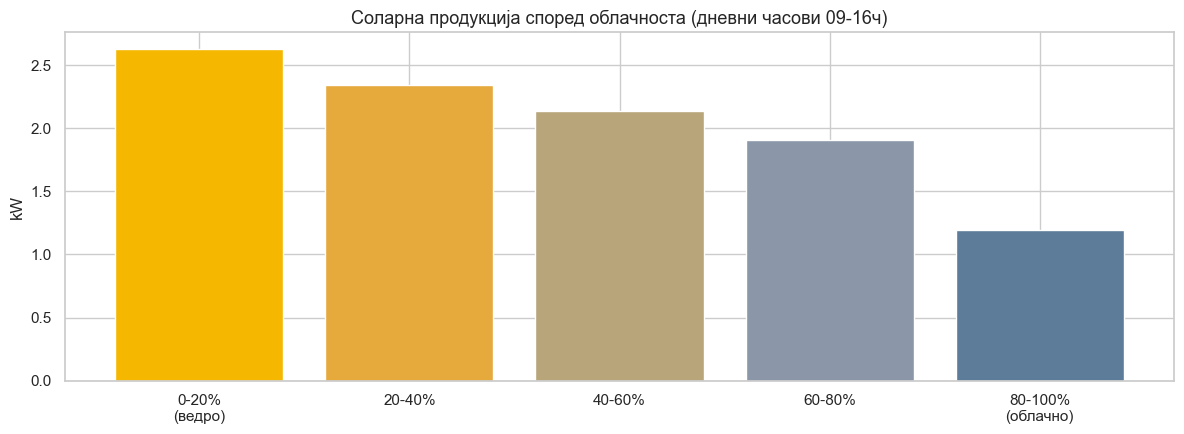

Од ведро до целосно облачно продукцијата паѓа за 55%


In [13]:
# Само дневни часови (ноќе нема сонце, ќе ја расипе сликата)
den = df[(df["cas"] >= 9) & (df["cas"] <= 16)].copy()
den["grupa"] = pd.cut(den["cloud_cover"], bins=[0, 20, 40, 60, 80, 100],
                      labels=["0-20%\n(ведро)", "20-40%", "40-60%", "60-80%", "80-100%\n(облачно)"],
                      include_lowest=True)

po_oblaci = den.groupby("grupa", observed=True)["pv_power_kw"].mean()

fig, ax = plt.subplots()
ax.bar(po_oblaci.index.astype(str), po_oblaci.values,
       color=["#F5B700", "#E5A93C", "#B8A67A", "#8B96A8", "#5C7C99"], edgecolor="white")
ax.set_title("Соларна продукција според облачноста (дневни часови 09-16ч)")
ax.set_ylabel("kW")
plt.tight_layout(); plt.show()

pad = (1 - po_oblaci.iloc[-1] / po_oblaci.iloc[0]) * 100
print(f"Од ведро до целосно облачно продукцијата паѓа за {pad:.0f}%")

### 📊 Графикон 4: Корелации

**Што прикажува:** колку секоја променлива е поврзана со продукцијата
(−1 = спротивно, 0 = никако, +1 = целосно).

**⚠ Внимание:** корелациите ги мериме **само за дневни часови (09-16ч)**.
Ако ги земеме сите 24 часа, ноќните нули (кога PV = 0 без оглед на времето)
ги разводнуваат вистинските врски и добиваме погрешна слика.

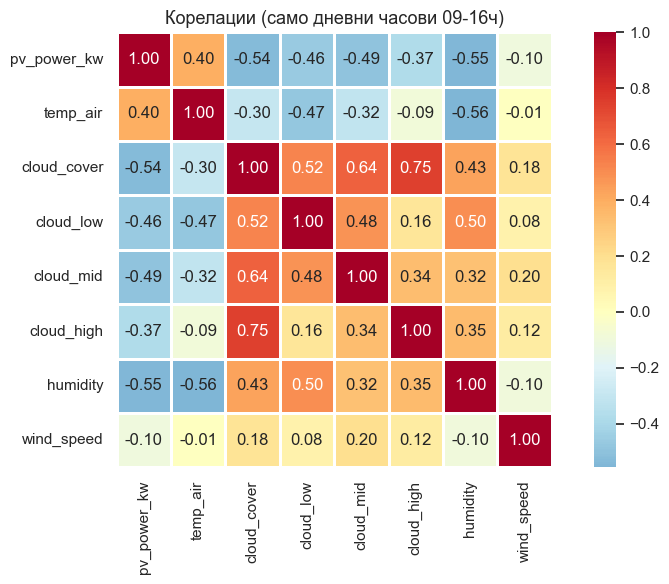

Најповрзани со соларната продукција:
  humidity       -0.547   ↓ помалку сонце
  cloud_cover    -0.536   ↓ помалку сонце
  cloud_mid      -0.492   ↓ помалку сонце
  cloud_low      -0.461   ↓ помалку сонце
  temp_air       +0.396   ↑ повеќе сонце
  cloud_high     -0.374   ↓ помалку сонце
  wind_speed     -0.105   ↓ помалку сонце


In [14]:
kolonite = ["pv_power_kw", "temp_air", "cloud_cover", "cloud_low",
            "cloud_mid", "cloud_high", "humidity", "wind_speed"]

# Само дневни часови — тогаш временските услови навистина прават разлика
korelacii = df[(df["cas"] >= 9) & (df["cas"] <= 16)][kolonite].corr()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(korelacii, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title("Корелации (само дневни часови 09-16ч)")
plt.tight_layout(); plt.show()

print("Најповрзани со соларната продукција:")
top = korelacii["pv_power_kw"].drop("pv_power_kw").sort_values(key=abs, ascending=False)
for ime, v in top.items():
    nasoka = "↑ повеќе сонце" if v > 0 else "↓ помалку сонце"
    print(f"  {ime:<14} {v:+.3f}   {nasoka}")

---
## 4. Feature engineering — што ќе „гледа" моделот

Суровите колони не се доволни. Ги трансформираме во форма што моделот
подобро ја разбира.

### 4.1 Циклично кодирање на времето

**Проблем:** час 23 и час 0 се **соседни** во реалноста, но како броеви
изгледаат далечни (23 vs 0). Истото важи за 31 декември и 1 јануари.

**Решение:** ги претвораме во точка на круг преку sin/cos:

$$\text{hour\_sin} = \sin\left(\frac{2\pi \cdot \text{час}}{24}\right),
\quad
\text{hour\_cos} = \cos\left(\frac{2\pi \cdot \text{час}}{24}\right)$$

Сега 23 и 0 се навистина блиску.

In [15]:
f = df.copy()
lok = f.index.tz_convert("Europe/Skopje")

# Час во денот — кружно кодирање
f["hour_sin"] = np.sin(2 * np.pi * lok.hour / 24)
f["hour_cos"] = np.cos(2 * np.pi * lok.hour / 24)

# Ден во годината — за сезоната
f["doy_sin"] = np.sin(2 * np.pi * lok.dayofyear / 365)
f["doy_cos"] = np.cos(2 * np.pi * lok.dayofyear / 365)

# Демонстрација дека функционира
proverka = pd.DataFrame({
    "час": [22, 23, 0, 1],
    "sin": np.sin(2*np.pi*np.array([22,23,0,1])/24).round(3),
    "cos": np.cos(2*np.pi*np.array([22,23,0,1])/24).round(3),
})
print("Час 23 и час 0 сега се соседни во sin/cos просторот:")
proverka

Час 23 и час 0 сега се соседни во sin/cos просторот:


,час,sin,cos
0,22,-0.500,0.866
1,23,-0.259,0.966
2,0,0.000,1.000
3,1,0.259,0.966


### 4.2 Изведени од облачноста

Три дополнителни трикови:

1. **`cloud_kvadrat`** — ефектот не е линеарен. Од 0% на 20% облаци не менува
   многу; од 80% на 100% менува драстично.
2. **`vedro` / `oblacno`** — јасни маркери за екстремните случаи.
3. **`cloud_efektivna`** — ⭐ **ниските облаци (стратус) го блокираат сонцето
   3× повеќе од високите (перјести)**. Затоа ги тежиме различно.

In [16]:
# 1. Нелинеарен ефект на облачноста
f["cloud_kvadrat"] = f["cloud_cover"] ** 2 / 100

# 2. Јасни маркери за екстремите
f["vedro"] = (f["cloud_cover"] < 20).astype(int)
f["oblacno"] = (f["cloud_cover"] > 70).astype(int)

# 3. Движење на облаците — доаѓа ли фронт?
f["cloud_pred"] = f["cloud_cover"].shift(1)      # претходен час
f["cloud_promena"] = f["cloud_cover"].diff()     # расте или опаѓа?

# 4. ⭐ Тежинска облачност: ниски × 3, средни × 1.5, високи × 0.5
f["cloud_efektivna"] = (3.0*f["cloud_low"] + 1.5*f["cloud_mid"] + 0.5*f["cloud_high"]) / 5.0

# 5. Вчерашна температура — индикатор за временска шема
f["temp_lag24"] = f["temp_air"].shift(24)

print("Создадени 7 изведени features:")
for x in ["cloud_kvadrat", "vedro", "oblacno", "cloud_pred",
          "cloud_promena", "cloud_efektivna", "temp_lag24"]:
    print(f"  · {x}")

Создадени 7 изведени features:
  · cloud_kvadrat
  · vedro
  · oblacno
  · cloud_pred
  · cloud_promena
  · cloud_efektivna
  · temp_lag24


### 4.3 Историски вредности (lag features)

**Идеја:** вчерашниот сончев ден е добар показател за денешниот.

**⚠️ Клучно правило:** сите lag-ови мора да бидат од **минатото**. Ако користиме
вредност од истиот час — тоа е измама (моделот „ѕирка" во иднината).

Забележи го трикот кај `pv_prosek7d`: прво `.shift(24)`, па потоа `.rolling()` —
за просекот **да не го содржи денешниот час**.

In [17]:
f["pv_lag24"]  = f["pv_power_kw"].shift(24)        # пред 1 ден
f["pv_lag48"]  = f["pv_power_kw"].shift(48)        # пред 2 дена
f["pv_lag168"] = f["pv_power_kw"].shift(24 * 7)    # пред 1 недела

# shift(24) ПРВО → просекот не го содржи тековниот час
f["pv_prosek7d"] = f["pv_power_kw"].shift(24).rolling(24 * 7).mean()

# Исфрли ги првите редови што немаат историја
pred = len(f)
f = f.dropna()
print(f"Отфрлени {pred - len(f)} реда без историја (првата недела)")
print(f"Останати: {len(f):,} примери за учење")

Отфрлени 191 реда без историја (првата недела)
Останати: 26,089 примери за учење


In [18]:
# ФИНАЛНА ЛИСТА НА FEATURES
FEATURES = [
    # Време (од календар — секогаш ги знаеме)
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    # Метео прогноза (ја имаме однапред за утре)
    "temp_air", "temp_lag24", "wind_speed", "humidity",
    "cloud_cover", "cloud_kvadrat", "vedro", "oblacno",
    "cloud_pred", "cloud_promena",
    "cloud_low", "cloud_mid", "cloud_high", "cloud_efektivna",
    # Историја (минати вредности — легитимно)
    "pv_lag24", "pv_lag48", "pv_lag168", "pv_prosek7d",
]
TARGET = "pv_power_kw"

print(f"Вкупно {len(FEATURES)} features:")
for i, x in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {x}")

Вкупно 22 features:
   1. hour_sin
   2. hour_cos
   3. doy_sin
   4. doy_cos
   5. temp_air
   6. temp_lag24
   7. wind_speed
   8. humidity
   9. cloud_cover
  10. cloud_kvadrat
  11. vedro
  12. oblacno
  13. cloud_pred
  14. cloud_promena
  15. cloud_low
  16. cloud_mid
  17. cloud_high
  18. cloud_efektivna
  19. pv_lag24
  20. pv_lag48
  21. pv_lag168
  22. pv_prosek7d


---
## 5. Поделба на податоците — ВРЕМЕНСКИ, не случајно

**⚠️ Најчестата грешка кај временски серии:** случајна поделба (`train_test_split`
со `shuffle=True`).

**Зошто е погрешно:** ако тренираш на јули и тестираш на јуни, моделот
ефективно „гледа во иднината" — резултатите изгледаат одлично, а во пракса
моделот не вреди.

**Правилно:** сечи по датум.

| Дел | Период | Улога |
|---|---|---|
| Train | јан 2021 – јун 2023 (30 мес) | моделот учи |
| Test | јул 2023 – дек 2023 (6 мес) | моделот **никогаш** не ги видел |

In [19]:
GRANICA = pd.Timestamp("2023-07-01", tz="UTC")

train = f[f.index < GRANICA]
test  = f[f.index >= GRANICA]

train_X, train_y = train[FEATURES], train[TARGET]
test_X,  test_y  = test[FEATURES],  test[TARGET]

print(f"TRAIN: {len(train):,} реда  ({train.index.min().date()} → {train.index.max().date()})")
print(f"TEST:  {len(test):,} реда  ({test.index.min().date()} → {test.index.max().date()})")
print(f"\nОднос: {len(train)/len(f)*100:.0f}% / {len(test)/len(f)*100:.0f}%")

TRAIN: 21,673 реда  (2021-01-08 → 2023-06-30)
TEST:  4,416 реда  (2023-07-01 → 2023-12-31)

Однос: 83% / 17%


### 📊 Графикон 5: Визуелна проверка на поделбата

Црвената линија е границата. Моделот учи само од **левата** страна.

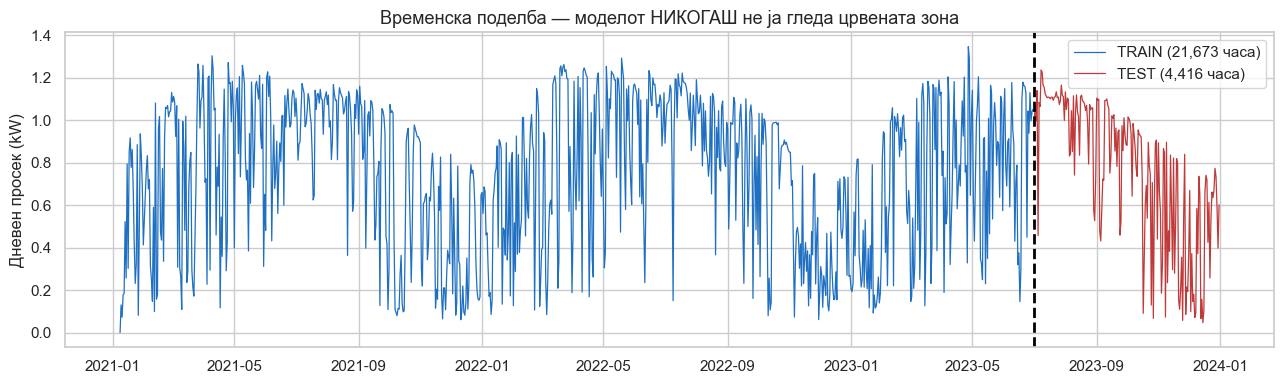

In [20]:
fig, ax = plt.subplots(figsize=(13, 4))
dnevno = f[TARGET].resample("D").mean()

ax.plot(dnevno[dnevno.index < GRANICA].index, dnevno[dnevno.index < GRANICA].values,
        color="#1F70C2", linewidth=0.9, label=f"TRAIN ({len(train):,} часа)")
ax.plot(dnevno[dnevno.index >= GRANICA].index, dnevno[dnevno.index >= GRANICA].values,
        color="#C03A3A", linewidth=0.9, label=f"TEST ({len(test):,} часа)")
ax.axvline(GRANICA, color="black", linestyle="--", linewidth=2)
ax.set_title("Временска поделба — моделот НИКОГАШ не ја гледа црвената зона")
ax.set_ylabel("Дневен просек (kW)"); ax.legend()
plt.tight_layout(); plt.show()

---
## 6. Baseline — со што се споредуваме?

Пред да тренираме модел, ни треба **референца**. Инаку не знаеме дали
резултатот е добар.

**Наивна прогноза (persistence):** „утре ќе биде исто како вчера во истиот час"

Ако нашиот модел не е подобар од ова глупаво правило — **не вреди ништо**.

In [21]:
naivna = test["pv_lag24"]

mae_naivna  = mean_absolute_error(test_y, naivna)
rmse_naivna = np.sqrt(mean_squared_error(test_y, naivna))
r2_naivna   = r2_score(test_y, naivna)

print("НАИВНА ПРОГНОЗА (утре = исто како вчера):")
print(f"  MAE:  {mae_naivna:.3f} kW")
print(f"  RMSE: {rmse_naivna:.3f} kW")
print(f"  R²:   {r2_naivna:.3f}")
print("\n← Ова е летвицата што мора да ја прескокнеме.")

НАИВНА ПРОГНОЗА (утре = исто како вчера):
  MAE:  0.231 kW
  RMSE: 0.593 kW
  R²:   0.730

← Ова е летвицата што мора да ја прескокнеме.


---
## 7. Споредба на алгоритми

Тестираме три пристапи за да го оправдаме изборот:

| Алгоритам | Како работи |
|---|---|
| **Линеарна регресија** | Права линија низ податоците |
| **Random Forest** | Многу дрва гласаат независно |
| **XGBoost** | Дрва што ги **коригираат грешките** на претходните |

In [22]:
modeli = {
    "Линеарна регресија": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=RANDOM_SEED, n_jobs=-1),
    # ⚠ ФЕР СПОРЕДБА: истата длабочина како Random Forest (12),
    # инаку XGBoost е хендикепиран со поплитки дрва.
    "XGBoost": XGBRegressor(
        n_estimators=600, max_depth=10, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_lambda=1.0,
        random_state=RANDOM_SEED, n_jobs=-1),
}

rezultati = []
prognozi = {}

for ime, model in modeli.items():
    print(f"Тренирам {ime}...", end=" ")
    model.fit(train_X, train_y)                  # ← УЧЕЊЕТО
    pred = np.clip(model.predict(test_X), 0, None)   # панели не даваат негативно
    prognozi[ime] = pred

    rezultati.append({
        "Модел": ime,
        "MAE": mean_absolute_error(test_y, pred),
        "RMSE": np.sqrt(mean_squared_error(test_y, pred)),
        "R²": r2_score(test_y, pred),
        "Подобрување vs наивна": f"{(1 - mean_absolute_error(test_y, pred)/mae_naivna)*100:.0f}%",
    })
    print("готово")

rezultati.append({"Модел": "── Наивна (baseline)", "MAE": mae_naivna,
                  "RMSE": rmse_naivna, "R²": r2_naivna, "Подобрување vs наивна": "—"})

pd.DataFrame(rezultati).round(3)

Тренирам Линеарна регресија... готово
Тренирам Random Forest... готово
Тренирам XGBoost... готово


,Модел,MAE,RMSE,R²,Подобрување vs наивна
0,Линеарна регресија,0.248,0.432,0.857,-7%
1,Random Forest,0.140,0.350,0.906,39%
2,XGBoost,0.152,0.365,0.897,34%
3,── Наивна (baseline),0.231,0.593,0.730,—


### 📊 Графикон 6: Кој алгоритам победи?

**Лево:** MAE — помало е подобро.
**Десно:** R² — поголемо е подобро.

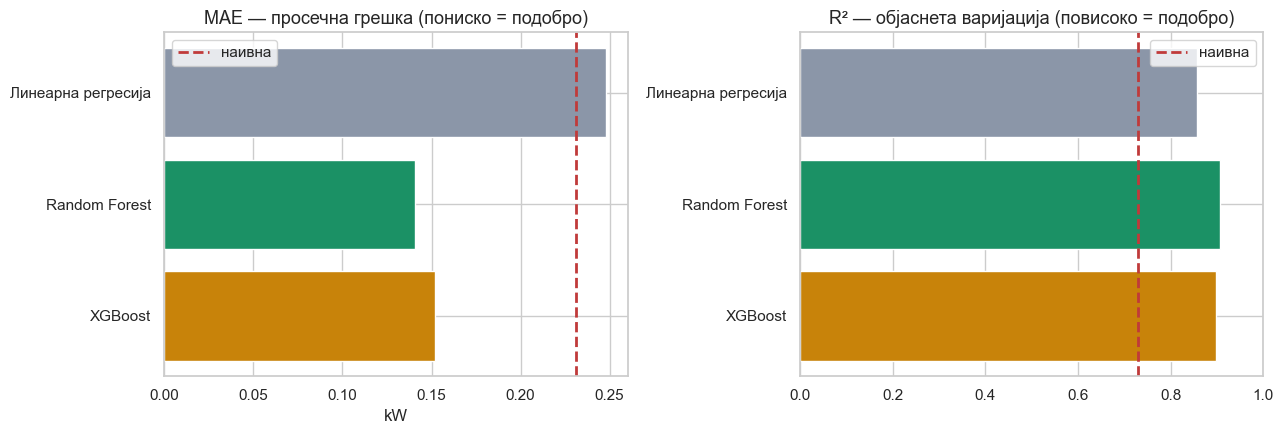

🏆 Победник: Random Forest


In [23]:
tab = pd.DataFrame(rezultati)
tab = tab[~tab["Модел"].str.startswith("──")]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
boi = ["#8B96A8", "#1B9165", "#C8830A"]

a1.barh(tab["Модел"], tab["MAE"], color=boi, edgecolor="white")
a1.axvline(mae_naivna, color="#C03A3A", linestyle="--", linewidth=2, label="наивна")
a1.set_title("MAE — просечна грешка (пониско = подобро)")
a1.set_xlabel("kW"); a1.legend(); a1.invert_yaxis()

a2.barh(tab["Модел"], tab["R²"], color=boi, edgecolor="white")
a2.axvline(r2_naivna, color="#C03A3A", linestyle="--", linewidth=2, label="наивна")
a2.set_title("R² — објаснета варијација (повисоко = подобро)")
a2.set_xlim(0, 1); a2.legend(); a2.invert_yaxis()

plt.tight_layout(); plt.show()

najdobar = tab.loc[tab["MAE"].idxmin(), "Модел"]
print(f"🏆 Победник: {najdobar}")

---
## 8. Финален модел — XGBoost

### Што прави XGBoost?

Гради **500 мали одлуковни дрва**. Секое дрво е серија прости прашања:

```
Дали е ноќ?           → да → 0 kW
Дали облачноста > 80%? → да → −1.5 kW
Дали е јули пладне?    → да → +2.5 kW
```

**Клучното:** секое следно дрво ги **поправа грешките** на претходните.
Тоа се вика *gradient boosting*. Финалната прогноза е **збир од сите 500 дрва**.

### Хиперпараметри

| Параметар | Вредност | Зошто |
|---|---|---|
| `n_estimators` | 600 | број на дрва |
| `max_depth` | 10 | доволно длабоко за сложени комбинации |
| `learning_rate` | 0.05 | мали чекори = стабилно учење |
| `subsample` | 0.8 | секое дрво гледа 80% од редовите |
| `colsample_bytree` | 0.8 | секое дрво гледа 80% од features |
| `min_child_weight` | 3 | барем 3 примери по лист (анти-overfit) |
| `reg_lambda` | 1.0 | L2 регуларизација |

> 💡 **Зошто `max_depth=10`, а не 6?**
> Во првата споредба XGBoost имаше длабочина 6, а Random Forest 12 — неправедно.
> Со изедначени услови XGBoost ја користи целата предност на boosting-от.

In [24]:
model = XGBRegressor(
    n_estimators=600,       # број на дрва
    max_depth=10,           # длабочина — доволно за сложени комбинации
    learning_rate=0.05,     # мали чекори = стабилно учење
    subsample=0.8,          # секое дрво гледа 80% од редовите
    colsample_bytree=0.8,   # секое дрво гледа 80% од features
    min_child_weight=3,     # барем 3 примери по лист (анти-overfit)
    reg_lambda=1.0,         # L2 регуларизација
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

# ══════════════ ОВА Е МОМЕНТОТ НА УЧЕЊЕ ══════════════
model.fit(train_X, train_y)
# ═════════════════════════════════════════════════════

pred_y = np.clip(model.predict(test_X), 0, None)

mae  = mean_absolute_error(test_y, pred_y)
rmse = np.sqrt(mean_squared_error(test_y, pred_y))
r2   = r2_score(test_y, pred_y)
podobruvanje = (1 - mae / mae_naivna) * 100

print("═" * 52)
print("РЕЗУЛТАТИ НА ТЕСТ (6 месеци што моделот не ги видел)")
print("═" * 52)
print(f"  MAE                    : {mae:.3f} kW")
print(f"  RMSE                   : {rmse:.3f} kW")
print(f"  R²                     : {r2:.3f}")
print(f"  MAE наивна             : {mae_naivna:.3f} kW")
print(f"  ⭐ Подобрување         : {podobruvanje:.0f}%")
print("═" * 52)

════════════════════════════════════════════════════
РЕЗУЛТАТИ НА ТЕСТ (6 месеци што моделот не ги видел)
════════════════════════════════════════════════════
  MAE                    : 0.152 kW
  RMSE                   : 0.365 kW
  R²                     : 0.897
  MAE наивна             : 0.231 kW
  ⭐ Подобрување         : 34%
════════════════════════════════════════════════════


### 📊 Графикон 7: Кои features се најважни?

**Што прикажува:** колку моделот се потпира на секој feature.

**Како да се чита:** ако `hour_cos` доминира — моделот главно го користи
часовникот (тривијално). Ако `cloud_*` се високо — навистина ги учи облаците.

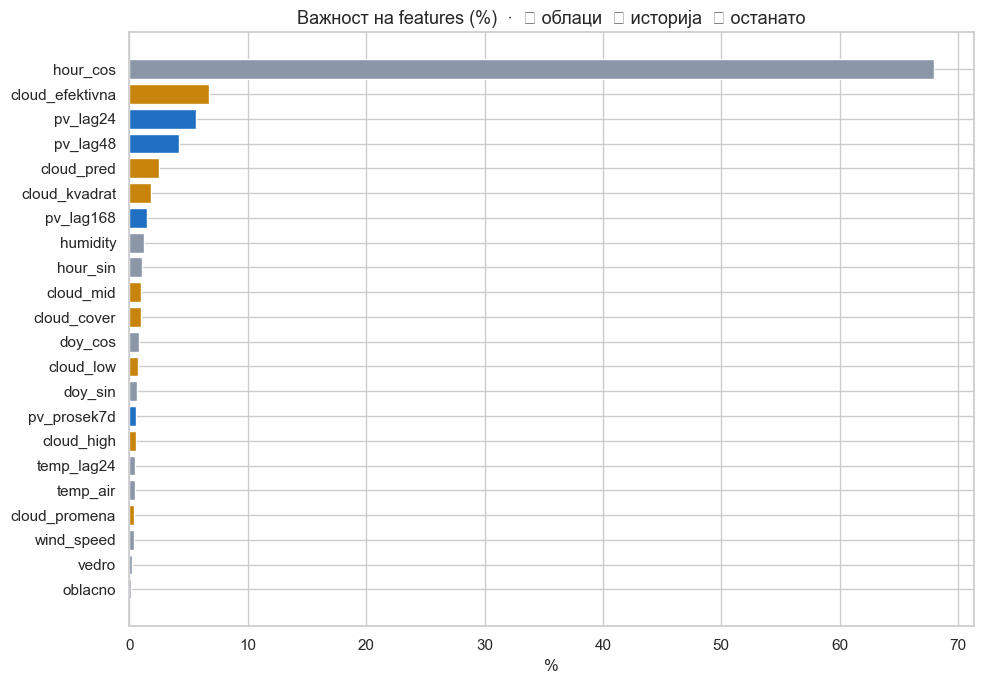

Топ 5:
  hour_cos            67.9%
  cloud_efektivna      6.8%
  pv_lag24             5.7%
  pv_lag48             4.2%
  cloud_pred           2.5%

Сите облачни features заедно: 14.7%


In [25]:
vaznost = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
boi = ["#C8830A" if "cloud" in x else "#1F70C2" if "pv_" in x else "#8B96A8"
       for x in vaznost.index]
ax.barh(vaznost.index, vaznost.values * 100, color=boi, edgecolor="white")
ax.set_title("Важност на features (%)  ·  🟠 облаци  🔵 историја  ⚪ останато")
ax.set_xlabel("%")
plt.tight_layout(); plt.show()

print("Топ 5:")
for ime, v in vaznost.sort_values(ascending=False).head().items():
    print(f"  {ime:<18} {v*100:5.1f}%")

oblaci_vkupno = sum(v for i, v in vaznost.items() if "cloud" in i) * 100
print(f"\nСите облачни features заедно: {oblaci_vkupno:.1f}%")

### 📊 Графикон 8: Прогноза vs реалност

**Што прикажува:** една недела од тест-периодот, час по час.

**Како да се чита:** колку двете линии се поклопуваат, толку моделот е подобар.
Разликите обично се кога наеднаш дошол облак.

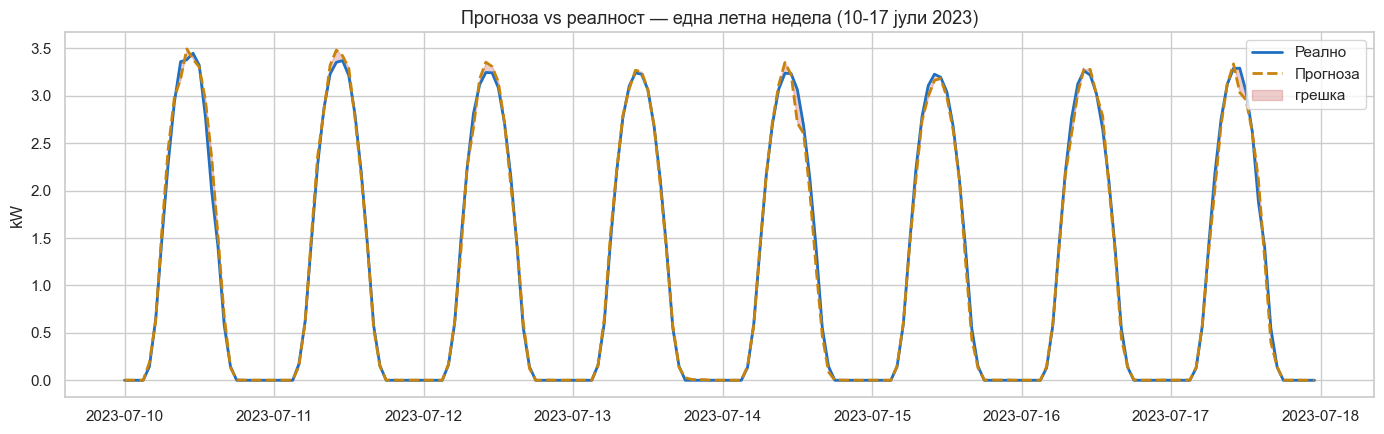

Грешка таа недела — MAE: 0.038 kW


In [26]:
sporedba = pd.DataFrame({"реално": test_y, "прогноза": pred_y}, index=test_X.index)
nedela = sporedba.loc["2023-07-10":"2023-07-17"]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(nedela.index, nedela["реално"], color="#1F70C2", linewidth=2, label="Реално")
ax.plot(nedela.index, nedela["прогноза"], color="#C8830A", linewidth=2,
        linestyle="--", label="Прогноза")
ax.fill_between(nedela.index, nedela["реално"], nedela["прогноза"],
                alpha=0.25, color="#C03A3A", label="грешка")
ax.set_title("Прогноза vs реалност — една летна недела (10-17 јули 2023)")
ax.set_ylabel("kW"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Грешка таа недела — MAE: {mean_absolute_error(nedela['реално'], nedela['прогноза']):.3f} kW")

### 📊 Графикон 9: Scatter — колку точно погодува?

**Што прикажува:** секоја точка е еден час. X = реално, Y = прогноза.

**Идеално:** сите точки на дијагоналата. Расејувањето е грешката.

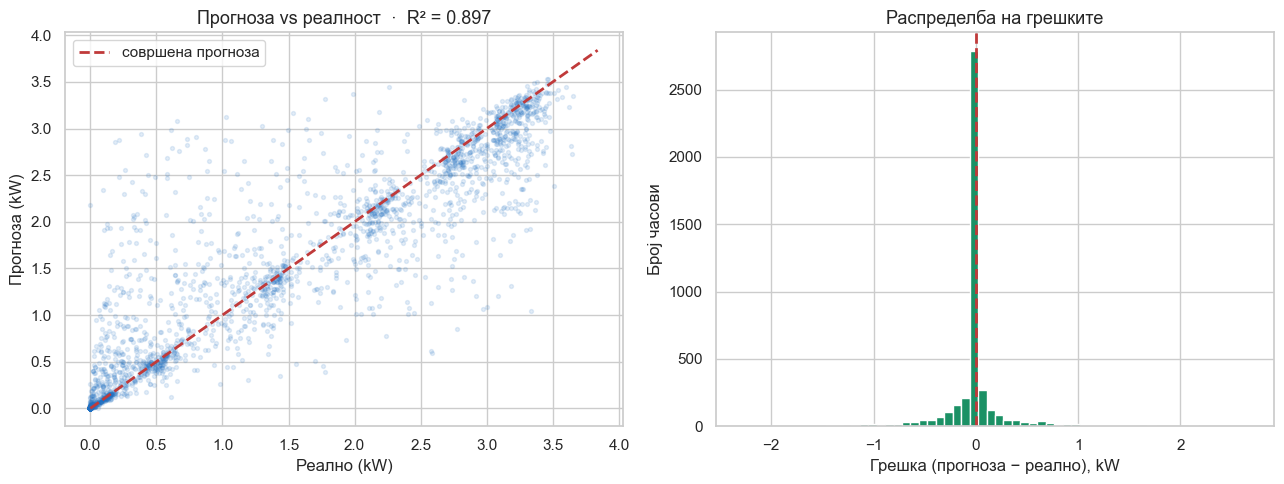

Просечна грешка (bias): +0.0122 kW
  → нема систематска пристрасност ✓
50% од грешките се под 0.004 kW
90% од грешките се под 0.496 kW


In [27]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

a1.scatter(test_y, pred_y, alpha=0.12, s=8, color="#1F70C2")
lim = max(test_y.max(), pred_y.max()) * 1.05
a1.plot([0, lim], [0, lim], "--", color="#C03A3A", linewidth=2, label="совршена прогноза")
a1.set_xlabel("Реално (kW)"); a1.set_ylabel("Прогноза (kW)")
a1.set_title(f"Прогноза vs реалност  ·  R² = {r2:.3f}")
a1.legend()

ostatoci = pred_y - test_y.values
a2.hist(ostatoci, bins=60, color="#1B9165", edgecolor="white")
a2.axvline(0, color="#C03A3A", linestyle="--", linewidth=2)
a2.set_xlabel("Грешка (прогноза − реално), kW"); a2.set_ylabel("Број часови")
a2.set_title("Распределба на грешките")

plt.tight_layout(); plt.show()

print(f"Просечна грешка (bias): {ostatoci.mean():+.4f} kW")
print(f"  → {'нема систематска пристрасност ✓' if abs(ostatoci.mean()) < 0.05 else 'има мала пристрасност'}")
print(f"50% од грешките се под {np.percentile(np.abs(ostatoci), 50):.3f} kW")
print(f"90% од грешките се под {np.percentile(np.abs(ostatoci), 90):.3f} kW")

### 📊 Графикон 10: Каде моделот греши најмногу?

**Што прикажува:** просечна грешка по час од денот.

**Очекувано:** ноќе ~0 (лесно е да се погоди нула), најголема грешка околу
пладне — тогаш облаците прават најголема разлика.

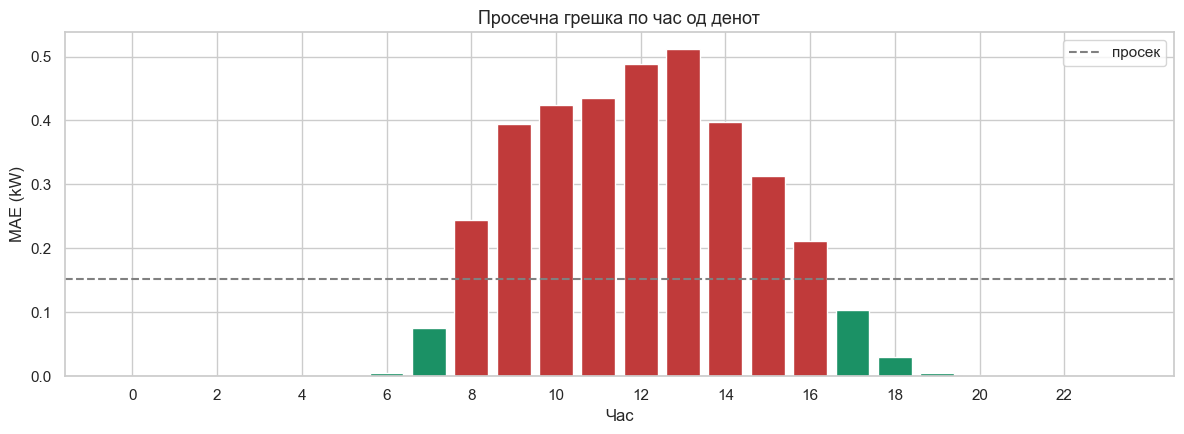

Најголема грешка: 13:00 ч (0.512 kW)
Ноќе (00-05ч):    0.0008 kW


In [28]:
sporedba["cas"] = sporedba.index.tz_convert("Europe/Skopje").hour
sporedba["greska"] = (sporedba["прогноза"] - sporedba["реално"]).abs()
po_cas_greska = sporedba.groupby("cas")["greska"].mean()

fig, ax = plt.subplots()
boi = ["#C03A3A" if v > po_cas_greska.mean() else "#1B9165" for v in po_cas_greska.values]
ax.bar(po_cas_greska.index, po_cas_greska.values, color=boi, edgecolor="white")
ax.axhline(po_cas_greska.mean(), color="gray", linestyle="--", label="просек")
ax.set_title("Просечна грешка по час од денот")
ax.set_xlabel("Час"); ax.set_ylabel("MAE (kW)")
ax.set_xticks(range(0, 24, 2)); ax.legend()
plt.tight_layout(); plt.show()

print(f"Најголема грешка: {po_cas_greska.idxmax()}:00 ч ({po_cas_greska.max():.3f} kW)")
print(f"Ноќе (00-05ч):    {po_cas_greska.loc[0:5].mean():.4f} kW")

---
## 9. Заклучок

### Резултати

Моделот предвидува **колку kW ќе произведат панелите во даден час**, врз основа
на 22 features: календарски, метеоролошки и историски.

Валидацијата е чесна — 6 месеци што моделот **никогаш** не ги видел.

### Три работи што го прават моделот веродостоен

1. **Нема data leakage** — `ghi` намерно е исклучен затоа што PVGIS ја пресметува
   PV моќноста директно од него. Сите features се познати однапред.

2. **Временска поделба** — не случајна. Моделот не „ѕирка во иднината".

3. **Споредба со baseline** — ако не е подобар од „утре = вчера", не вреди.

### Каде оди прогнозата понатаму?

```
XGBoost: „утре во 12ч ќе има 4.2 kW"
        ↓
LP (PuLP + CBC): „тогаш полни ја батеријата напладне,
                  испразни ја во 19ч кога струјата е скапа"
        ↓
Резултат: минимална сметка за струја
```

Тоа е содржината на `lp_optimizacija.py` во главниот проект.

### Ограничувања

- Прогнозата за облаци е **историски измерена**, не вистинска прогноза.
  Во реален deployment грешката би била малку поголема.
- Load профилот е синтетички (нема јавни smart-meter податоци во Македонија).

In [29]:
# Зачувај го моделот за употреба во апликацијата
import joblib
joblib.dump({"model": model, "features": FEATURES}, "data/xgb_model.joblib")
print("✓ Моделот е зачуван во data/xgb_model.joblib")
print(f"✓ Финален резултат: MAE {mae:.3f} kW · R² {r2:.3f} · {podobruvanje:.0f}% подобрување")

✓ Моделот е зачуван во data/xgb_model.joblib
✓ Финален резултат: MAE 0.152 kW · R² 0.897 · 34% подобрување
